2026-04-14 17:25:18.101045: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-14 17:25:18.157282: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 17:25:18.438455: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/drivex/Ali/waymo_env/lib/python3.10/site-packages/nvidia/cudnn/lib:/home/drivex/Ali/waymo_en

Loading data and calculating transformations...


2026-04-14 17:25:18.977154: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-14 17:25:18.990566: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-14 17:25:18.992741: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-14 17:25:18.994246: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuil

Transformation Complete!


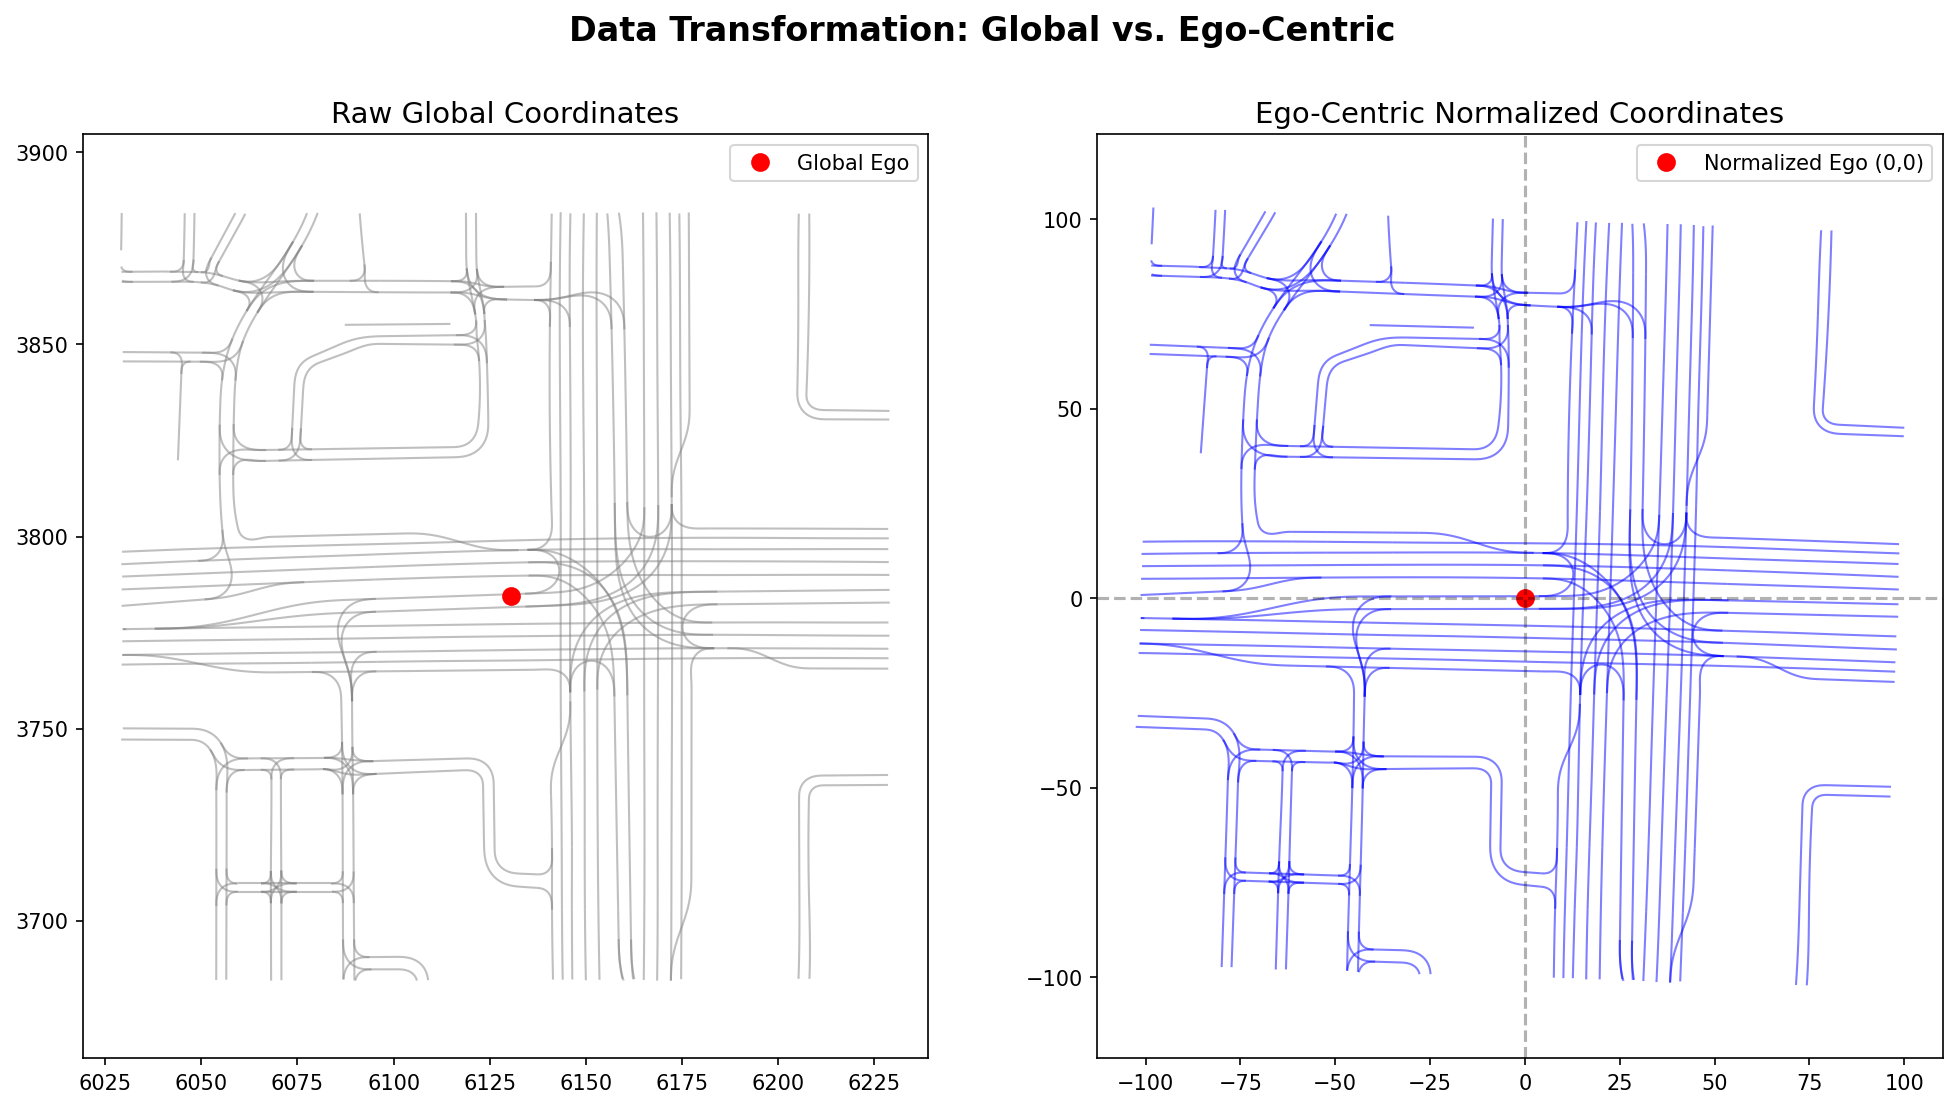

In [1]:
import tensorflow as tf
import matplotlib
matplotlib.use('Agg') # Server-safe backend
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
import math
import glob
from waymo_open_dataset.protos import scenario_pb2
from IPython.display import Image, display

print("Loading data and calculating transformations...")

# Math Function
def normalize(x, y, e_x, e_y, e_h):
    dx, dy = x - e_x, y - e_y
    cos_h, sin_h = math.cos(-e_h), math.sin(-e_h)
    return (dx * cos_h - dy * sin_h), (dx * sin_h + dy * cos_h)

file_paths = glob.glob('../data/raw/*.tfrecord*')
dataset = tf.data.TFRecordDataset(file_paths[:1])
for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())

# getting Ego State
ego_track = scenario.tracks[scenario.sdc_track_index]
e_x = ego_track.states[10].center_x
e_y = ego_track.states[10].center_y
e_h = ego_track.states[10].heading

# Extract Lines (Optimized)
raw_lines = []
norm_lines = []

for feature in scenario.map_features:
    if feature.HasField('lane'):
        raw_pts = [(pt.x, pt.y) for pt in feature.lane.polyline]
        if raw_pts:
            raw_lines.append(raw_pts)
            # calculating the normalized version of the line
            norm_pts = [normalize(pt[0], pt[1], e_x, e_y, e_h) for pt in raw_pts]
            norm_lines.append(norm_pts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Data Transformation: Global vs. Ego-Centric", fontsize=16, fontweight='bold')

# Drawing Raw Map (Left)
ax1.add_collection(mcoll.LineCollection(raw_lines, colors='gray', alpha=0.5, linewidths=1))
ax1.plot(e_x, e_y, 'ro', markersize=8, label='Global Ego')
ax1.autoscale()
ax1.axis('equal')
ax1.set_title("Raw Global Coordinates", fontsize=14)
ax1.legend()

# Drawing Normalized Map (Right)
ax2.add_collection(mcoll.LineCollection(norm_lines, colors='blue', alpha=0.5, linewidths=1))
ax2.plot(0, 0, 'ro', markersize=8, label='Normalized Ego (0,0)')
ax2.axhline(0, color='black', linestyle='--', alpha=0.3) # X-axis crosshair
ax2.axvline(0, color='black', linestyle='--', alpha=0.3) # Y-axis crosshair
ax2.autoscale()
ax2.axis('equal')
ax2.set_title("Ego-Centric Normalized Coordinates", fontsize=14)
ax2.legend()

plt.savefig('temp_transform.png', dpi=150, bbox_inches='tight')
plt.close()

print("Transformation Complete!")
display(Image('temp_transform.png'))